# HackIA 2026 — Pipeline YOLO

Détection multi-classes (clef, smartphone, télécommande, sac) avec YOLOv8.

**Pipeline** : split dataset → génération yaml → vérification → nettoyage → entraînement → prédiction.

## 0. Vérification du répertoire de travail

In [ ]:
!pwd

## 1. Split du dataset source

Source : `four_classes/` (~4 219 images annotées au format YOLO).

**Ratios appliqués : 80 % train / 15 % val / 5 % test.** Le val à 15 % garantit un échantillon suffisant pour piloter l'early stopping (à 5 %, le val ne contenait que 16 instances évaluées, ce qui rend les métriques par classe non significatives).

**Structure de sortie** : `<split>/images` et `<split>/labels` (format aligné avec le reste du pipeline).

In [4]:
import random
import shutil
from pathlib import Path

# ---- Configuration ----
SOURCE = Path("four_classes/")            # dataset source
IMAGES_DIR = SOURCE / "images"
LABELS_DIR = SOURCE / "labels"

OUTPUT = Path("four_classes_split")       # sera référencé dans dataset.yaml
RATIOS = {"train": 0.80, "val": 0.15, "test": 0.05}
SEED = 42
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MOVE = False                              # True = move, False = copy (recommandé)

# ---- Validation ----
assert abs(sum(RATIOS.values()) - 1.0) < 1e-6, "Les ratios doivent sommer à 1.0"
assert IMAGES_DIR.is_dir(), f"Introuvable : {IMAGES_DIR}"
assert LABELS_DIR.is_dir(), f"Introuvable : {LABELS_DIR}"

# ---- Appariement image / label (exclut .DS_Store et autres fichiers cachés) ----
images = sorted(
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTS and not p.name.startswith(".")
)
pairs, orphans_img, orphans_lbl = [], [], []

for img in images:
    label = LABELS_DIR / f"{img.stem}.txt"
    if label.exists():
        pairs.append((img, label))
    else:
        orphans_img.append(img)

image_stems = {img.stem for img in images}
for lbl in LABELS_DIR.glob("*.txt"):
    if lbl.stem not in image_stems:
        orphans_lbl.append(lbl)

print(f"Images totales : {len(images)}")
print(f"Paires valides : {len(pairs)}")
if orphans_img:
    print(f"Images sans label (ignorées) : {len(orphans_img)}")
if orphans_lbl:
    print(f"Labels sans image (ignorés)  : {len(orphans_lbl)}")

# ---- Shuffle déterministe + découpage ----
random.seed(SEED)
random.shuffle(pairs)

n = len(pairs)
n_train = int(n * RATIOS["train"])
n_val = int(n * RATIOS["val"])
splits = {
    "train": pairs[:n_train],
    "val":   pairs[n_train:n_train + n_val],
    "test":  pairs[n_train + n_val:],   # reliquat dans test
}

# ---- Création de l'arborescence (format <split>/images + <split>/labels) ----
for split in splits:
    (OUTPUT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT / split / "labels").mkdir(parents=True, exist_ok=True)

# ---- Transfert ----
op = shutil.move if MOVE else shutil.copy2
for split, items in splits.items():
    for img, label in items:
        op(str(img),   str(OUTPUT / split / "images" / img.name))
        op(str(label), str(OUTPUT / split / "labels" / label.name))
    print(f"{split:5s} : {len(items)} échantillons")

print("Split terminé.")

Images totales : 4219
Paires valides : 4219
train : 3375 échantillons
val   : 632 échantillons
test  : 212 échantillons
Split terminé.


## 2. Définition du chemin de travail et du dataset.yaml

On pointe vers le dataset issu du split. Le fichier `dataset.yaml` est généré dynamiquement pour rester cohérent avec la structure produite.

In [18]:
import os
from pathlib import Path

# Racine du projet
my_drive_path = "/home/abdellah/"

# Dossier dataset issu du split (cohérent avec la cellule précédente)
shared_folder_path = os.path.join(my_drive_path, "four_classes_split")

# Vérification du contenu
print(f"Contenu de {shared_folder_path} :")
print(sorted(os.listdir(shared_folder_path)))

Contenu de /home/abdellah/four_classes_split :
['dataset.yaml', 'test', 'train', 'val']


In [19]:
# Génération du dataset.yaml en cohérence avec la structure du split
import yaml

CLASSES_MAP = {
    0: "clef",
    1: "telecommande",
    2: "sac",
    3: "smartphone",
}

dataset_config = {
    "path": shared_folder_path,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": CLASSES_MAP,
}

yaml_path = os.path.join(shared_folder_path, "dataset.yaml")
with open(yaml_path, "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False, allow_unicode=True)

print(f"dataset.yaml généré : {yaml_path}")
print("---")
with open(yaml_path) as f:
    print(f.read())

dataset.yaml généré : /home/abdellah/four_classes_split/dataset.yaml
---
path: /home/abdellah/four_classes_split
train: train/images
val: val/images
test: test/images
names:
  0: clef
  1: telecommande
  2: sac
  3: smartphone



## 3. Vérification des paires image / label sur les trois splits

Le split garantit déjà l'appariement, mais on vérifie pour confirmer.

In [20]:
import os

IMAGE_EXTS_TUPLE = (".jpg", ".jpeg", ".png")

for split in ["train", "val", "test"]:
    images_dir = os.path.join(shared_folder_path, split, "images")
    labels_dir = os.path.join(shared_folder_path, split, "labels")

    images = {
        os.path.splitext(f)[0]
        for f in os.listdir(images_dir)
        if f.lower().endswith(IMAGE_EXTS_TUPLE)
    }
    labels = {
        os.path.splitext(f)[0]
        for f in os.listdir(labels_dir)
        if f.endswith(".txt")
    }

    images_sans_label = images - labels
    labels_sans_image = labels - images

    print(f"[{split}] images={len(images)} | labels={len(labels)} | "
          f"orphelins img={len(images_sans_label)} | orphelins lbl={len(labels_sans_image)}")

[train] images=3362 | labels=3362 | orphelins img=0 | orphelins lbl=0
[val] images=629 | labels=629 | orphelins img=0 | orphelins lbl=0
[test] images=212 | labels=212 | orphelins img=0 | orphelins lbl=0


## 4. Nettoyage et statistiques des classes

Une seule passe de nettoyage appliquée aux trois splits via une fonction réutilisable. Supprime les images corrompues, les orphelins, et produit la distribution des classes par split.

In [21]:
import os
from PIL import Image

IMAGE_EXTS_TUPLE = (".jpg", ".jpeg", ".png")


def nettoyer_split(images_dir, labels_dir, classes_map):
    """Nettoie un split (images corrompues, orphelins) et retourne la distribution des classes."""
    if not os.path.isdir(images_dir) or not os.path.isdir(labels_dir):
        print(f"ERREUR : dossiers introuvables ({images_dir} / {labels_dir})")
        return None

    fichiers_images = [f for f in os.listdir(images_dir) if f.lower().endswith(IMAGE_EXTS_TUPLE)]
    compteur_suppr = 0
    stats_classes = {k: 0 for k in classes_map}

    # Pass 1 : images corrompues ou orphelines
    for nom_img in fichiers_images:
        chemin_img = os.path.join(images_dir, nom_img)
        nom_base = os.path.splitext(nom_img)[0]
        chemin_label = os.path.join(labels_dir, nom_base + ".txt")

        try:
            with Image.open(chemin_img) as img:
                img.verify()
        except (IOError, SyntaxError):
            os.remove(chemin_img)
            if os.path.exists(chemin_label):
                os.remove(chemin_label)
            compteur_suppr += 1
            continue

        if not os.path.exists(chemin_label):
            os.remove(chemin_img)
            compteur_suppr += 1
            continue

        # Statistiques de classe
        with open(chemin_label, "r") as f:
            for ligne in f:
                elements = ligne.strip().split()
                if elements:
                    id_classe = int(elements[0])
                    if id_classe in stats_classes:
                        stats_classes[id_classe] += 1

    # Pass 2 : labels sans image correspondante
    for nom_txt in os.listdir(labels_dir):
        if not nom_txt.lower().endswith(".txt"):
            continue
        nom_base = os.path.splitext(nom_txt)[0]
        existe_image = any(
            os.path.exists(os.path.join(images_dir, nom_base + ext))
            for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]
        )
        if not existe_image:
            os.remove(os.path.join(labels_dir, nom_txt))

    return {"supprimes": compteur_suppr, "stats": stats_classes}


# Application aux trois splits
bilan_global = {}
for split in ["train", "val", "test"]:
    images_dir = os.path.join(shared_folder_path, split, "images")
    labels_dir = os.path.join(shared_folder_path, split, "labels")
    bilan = nettoyer_split(images_dir, labels_dir, CLASSES_MAP)
    if bilan is None:
        continue
    bilan_global[split] = bilan
    nb_restantes = len(os.listdir(images_dir))
    print(f"[{split}] supprimés : {bilan['supprimes']} | images restantes : {nb_restantes}")

print("\nDistribution des classes par split :")
print(f"{'split':<8} | " + " | ".join(f"{nom:<14}" for nom in CLASSES_MAP.values()))
print("-" * 70)
for split, bilan in bilan_global.items():
    ligne = f"{split:<8} | " + " | ".join(
        f"{bilan['stats'][k]:<14}" for k in CLASSES_MAP
    )
    print(ligne)

[train] supprimés : 0 | images restantes : 3362
[val] supprimés : 0 | images restantes : 629
[test] supprimés : 0 | images restantes : 212

Distribution des classes par split :
split    | clef           | telecommande   | sac            | smartphone    
----------------------------------------------------------------------
train    | 65             | 2519           | 2188           | 1870          
val      | 9              | 393            | 354            | 398           
test     | 2              | 182            | 129            | 167           


## 5. Configuration Weights & Biases

W&B (Weights & Biases — plateforme de suivi d'expériences) permet de tracer les métriques d'entraînement en temps réel.

In [22]:
!yolo settings wandb=True

✅ Updated 'wandb=True'
JSONDict("/home/abdellah/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/home/abdellah/HACKIA_2026_codebase/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "9d6baa34215a2885c5c5ac729d42e2e8f6582721e2d32f4c41d71efa95ec3ae5",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": true,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


Clé API W&B (à utiliser via `wandb login` ou variable d'environnement `WANDB_API_KEY`) :

```
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
```

**Note de sécurité** : cette clé est exposée en clair dans le notebook. À régénérer après le hackathon.

## 6. Entraînement YOLOv8

YOLO (You Only Look Once — architecture de détection d'objets en une passe). Modèle : `yolov8n.pt` (version nano, la plus légère).

In [23]:
# Activation W&B avant import de YOLO pour que Ultralytics enregistre les callbacks
from ultralytics import settings

settings.update({"wandb": True})

# Reload des callbacks si ultralytics a déjà été importé dans le kernel
import importlib
import ultralytics.utils.callbacks.wb as _wb_callbacks

importlib.reload(_wb_callbacks)

from ultralytics import YOLO

# Ne pas appeler wandb.init() ici — Ultralytics crée le run automatiquement
model = YOLO("yolo26s.pt")

model.train(
    data=os.path.join(shared_folder_path, "dataset.yaml"),
    epochs=100,
    imgsz=640,
    name="yolov26s_four_classes",
    project="hackia_project",
    patience=30,   # early stopping si pas d'amélioration sur 30 époques
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080, 15954MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/abdellah/four_classes_split/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mo

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See ht

lr/pg0,▃▆███▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁
lr/pg1,▃▆████▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁
lr/pg2,▆████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▁▁▁
metrics/mAP50(B),▁▃▄▄▆▆▅▆▆▆▆▇▆▆▇▇▇▇▆▇▇▇██▇▇▇███████████▇█
metrics/mAP50-95(B),▁▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▆▆▇▆▇▇▇▇▇██▇████▇▇▇▇
metrics/precision(B),▃▃▁▂▅▃▄▅▅▅▅▄▅▅▅▅▆▅▆▄▄█▅▅▅▆▅▆▆▇▇▆▇▇▇▆▅█▆█
metrics/recall(B),▃▁▁▂▂▄▃▄▆▄▆▅▅▅▅▆▆▅▅▆▇▅█▇▇▆█▇█▇▇▆▇▇█▇▆█▆▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x70b53e4192e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 7. Prédiction sur une image de validation

Récupération automatique du `best.pt` le plus récent du projet, pour éviter de devoir corriger le suffix (`_four_classes`, `_four_classes2`, etc.) à chaque relance.

Modèle chargé : runs/detect/hackia_project/yolov8n_four_classes/weights/best.pt
Image testée : /home/abdellah/four_classes_split/val/images/000000000257.jpg

image 1/1 /home/abdellah/four_classes_split/val/images/000000000257.jpg: 480x640 1 telecommande, 2.1ms
Speed: 0.6ms preprocess, 2.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


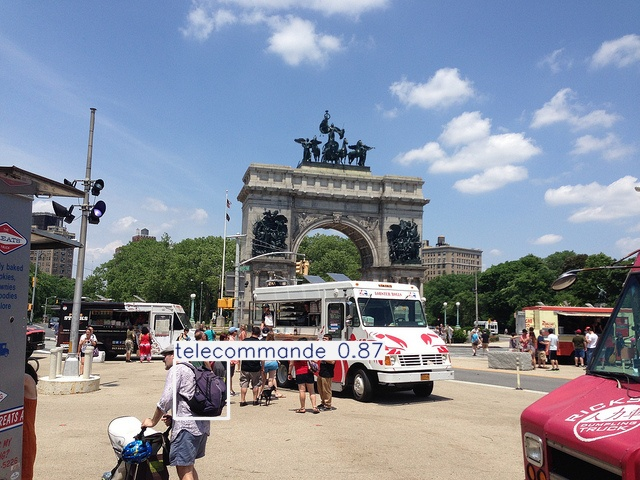

In [24]:
from ultralytics import YOLO
from PIL import Image
from pathlib import Path

# 1. Récupération dynamique du best.pt le plus récent
runs_root = Path("runs/detect/hackia_project")
candidats = sorted(
    runs_root.glob("yolov8n_four_classes*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
assert candidats, "Aucun best.pt trouvé. L'entraînement a-t-il bien produit un modèle ?"
chemin_modele = candidats[0]
print(f"Modèle chargé : {chemin_modele}")

mon_modele = YOLO(str(chemin_modele))

# 2. Sélection d'une image de val au hasard
val_images_dir = Path(shared_folder_path) / "val" / "images"
images_val = sorted(p for p in val_images_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
assert images_val, f"Aucune image dans {val_images_dir}"
chemin_test_reel = str(images_val[0])
print(f"Image testée : {chemin_test_reel}")

# 3. Inférence et visualisation
resultats = mon_modele(chemin_test_reel)
resultats[0].save(filename="visualisation_test.jpg")
Image.open("visualisation_test.jpg")

In [ ]:
!ls